In [2]:
import numpy as np
import h5py
import bacco
import os
import matplotlib.pyplot as plt
import struct

In [3]:
bacco.config['growth']['method'] = 'reps'

In [4]:
os.chdir('/mnt/ceph/users/fmaion/projects/bias_priors/src')
import utils

In [5]:
#for i in range(8):
i=0
with open("/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/ICs/ics.{:d}".format(i), "rb") as f:
    fileContent = f.read()

In [6]:
ofs = 0
header_size = struct.unpack("<i", fileContent[:4]); ofs += 4
NumPart = struct.unpack("<iiiiii", fileContent[ofs:ofs+6*4]); ofs +=6*4 
Mass = struct.unpack("<dddddd", fileContent[ofs:ofs+6*8]); ofs+=6*8
Time = struct.unpack("<d", fileContent[ofs:ofs+8]); ofs += 8
Redshift = struct.unpack("<d", fileContent[ofs:ofs+8]); ofs += 8
FlagSFR = struct.unpack("<I", fileContent[ofs:ofs+4]); ofs += 4
FlagFeedback = struct.unpack("<I", fileContent[ofs:ofs+4]); ofs += 4
Nall = struct.unpack("<IIIIII", fileContent[ofs:ofs+6*4]); ofs += 6*4
FlagCooling = struct.unpack("<I", fileContent[ofs:ofs+4]); ofs += 4
NumFiles = struct.unpack("<I", fileContent[ofs:ofs+4]); ofs += 4
BoxSize = struct.unpack("<d", fileContent[ofs:ofs+8]); ofs += 8
closer = struct.unpack("<I", fileContent[260:264])

print("Numpart =", NumPart)
print("Time = ", Time)
print("Redshift = ", Redshift)
print("Nall = ", Nall)
print("FlagSFR = ", FlagSFR)
print("FlagFeedback = ", FlagFeedback)
print("FlagCooling = ", FlagCooling)
print("NumFiles = ", NumFiles)
print("BoxSize = ", BoxSize)

ofs = 264

Numpart = (16777216, 16777216, 0, 0, 0, 0)
Time =  (0.0078125,)
Redshift =  (127.0,)
Nall =  (134217728, 134217728, 0, 0, 0, 0)
FlagSFR =  (0,)
FlagFeedback =  (0,)
FlagCooling =  (0,)
NumFiles =  (8,)
BoxSize =  (50000.0,)


In [7]:
def read_int_prop(fileContent, type, add_offset=0):
    offset = 264 + add_offset
    b_size = struct.unpack("<I", fileContent[offset:offset+4])[0]
    offset += 4

    gas_prop = read_block_int(fileContent, offset, b_size//2, type)
    offset += b_size//2

    dm_prop = read_block_int(fileContent, offset, b_size//2, type)

    return gas_prop, dm_prop

def read_block_int(fileContent, offset, b_size, type):
    if type=='32':
        unit = 4
        type_str = "i"
    elif type=='64':
        unit = 8
        type_str = "q"

    print("Unit per particle is of {:d} bytes".format(unit))
    print("There are {:d} bytes left not being read".format(b_size%unit))
    b_np = b_size // unit
    print("The number of particles is {:d}".format(b_np))
    
    buffer = np.asarray(struct.unpack("<"+b_np*type_str, fileContent[offset:offset + b_size]))

    return buffer

In [8]:
def read_vec_prop(fileContent, type, add_offset=0):
    # Read the first block
    offset = 264 + add_offset
    b_size = struct.unpack("<I", fileContent[offset:offset+4])[0]
    offset += 4
    
    gas_prop = read_block_vec(fileContent, offset, b_size//2, type)
    offset += b_size//2

    dm_prop = read_block_vec(fileContent, offset, b_size//2, type)
    
    return gas_prop, dm_prop
    
def read_block_vec(fileContent, offset, b_size, type):
    if type=='float':
        unit = 4 * 3
        type_str = "f"
    elif type=='double':
        unit = 8 * 3
        type_str = "d"
        
    print("Unit per particle is of {:d} bytes".format(unit))
    print("There are {:d} bytes left not being read".format(b_size%unit))
    b_np = b_size // unit
    print("The number of particles is {:d}".format(b_np))

    buffer = np.asarray(struct.unpack("<"+b_np*3*type_str, fileContent[offset:offset + b_np * unit]))
    b_pos = np.reshape(buffer, (b_np, 3))

    return b_pos

In [52]:
for i in range(8):
    with open("/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/ICs/ics.{:d}".format(i), "rb") as f:
        fileContent = f.read()

    if i==0:
        gas_pos, dm_pos = read_vec_prop(fileContent, 'float')
        #gas_vel, dm_vel = read_vec_prop(fileContent, 'float', add_offset=256**3*24+4)
        gas_ID, dm_ID = read_int_prop(fileContent, '32', add_offset=2*256**3*24+16)
    else:
        _, tmp_dm_pos = read_vec_prop(fileContent, 'float')
        _, tmp_dm_ID = read_int_prop(fileContent, '32', add_offset=2*256**3*24+16)

        dm_pos = np.concatenate((dm_pos, tmp_dm_pos), axis=0)
        dm_ID = np.concatenate((dm_ID, tmp_dm_ID), axis=0)       

Unit per particle is of 12 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 12 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 4 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 4 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 12 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 12 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 4 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 4 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 12 bytes
There are 0 bytes left not being read
The number of particles is 16777216
Unit per particle is of 12 bytes
There ar

In [55]:
dm_d3d = np.empty((512**3, 3))
dm_pos_rec = utils.dmpos_from_ids(dm_ID, 50000/512)
    
dm_d3d = dm_pos - dm_pos_rec
for j in range(3):
    sel = np.where(dm_d3d[:,j]>25000)[0]
    dm_d3d[sel,j] = dm_d3d[sel,j] - 50000
    
    sel = np.where(dm_d3d[:,j]<-25000)[0]
    dm_d3d[sel,j] = dm_d3d[sel,j] + 50000

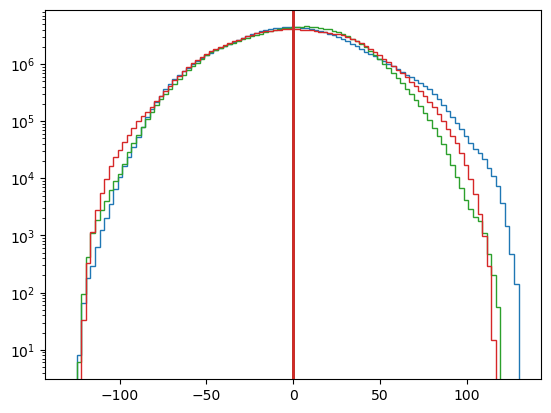

In [77]:
fig, ax = plt.subplots(dpi=100)

ax.set_yscale("log")

ax.hist(dm_d3d[:,0], histtype='step', bins=np.linspace(-130,130,100), color='C0');
ax.hist(dm_d3d[:,1], histtype='step', bins=np.linspace(-130,130,100), color='C2');
ax.hist(dm_d3d[:,2], histtype='step', bins=np.linspace(-130,130,100), color='C3');

ax.axvline(np.mean(dm_d3d[:,0]), color='C0', lw=2)
ax.axvline(np.mean(dm_d3d[:,1]), color='C2', lw=2)
ax.axvline(np.mean(dm_d3d[:,2]), color='C3', lw=2)

In [56]:
dm_dist = np.sqrt( np.sum( dm_d3d**2, axis=1 ) )

In [57]:
print(dm_pos[0,:])
print(dm_pos_rec[0,:])

[4.99733555e+04 2.41196136e+01 4.98935938e+00]
[48.828125 48.828125 48.828125]


In [62]:
print("Mean Distance for DM", np.mean(dm_d3d, axis=0))
print("Median Distance for DM", np.median(dm_d3d, axis=0))

Mean Distance for DM [-2.41183713e-08  8.33270203e-08 -7.03825507e-08]
Median Distance for DM [-0.67895508  1.56054688  0.25439453]


In [59]:
for i in range(10):
    print("ID {:d}, x: {:.4f} y: {:.4f} z: {:.4f} ".format(dm_ID[i], dm_pos[i,0], dm_pos[i,1], dm_pos[i,2]))
    print("ID {:d}, _x: {:.4f} _y: {:.4f} _z: {:.4f} ".format(dm_ID[i], dm_pos_rec[i,0], dm_pos_rec[i,1], dm_pos_rec[i,2]))  

ID 262145, x: 49973.3555 y: 24.1196 z: 4.9894 
ID 262145, _x: 48.8281 _y: 48.8281 _z: 48.8281 
ID 262146, x: 49974.4531 y: 21.5078 z: 100.3769 
ID 262146, _x: 48.8281 _y: 48.8281 _z: 146.4844 
ID 262147, x: 49974.8477 y: 19.3045 z: 196.6895 
ID 262147, _x: 48.8281 _y: 48.8281 _z: 244.1406 
ID 262148, x: 49974.7344 y: 18.3793 z: 294.5527 
ID 262148, _x: 48.8281 _y: 48.8281 _z: 341.7969 
ID 262149, x: 49974.4648 y: 15.3238 z: 394.4136 
ID 262149, _x: 48.8281 _y: 48.8281 _z: 439.4531 
ID 262150, x: 49974.2617 y: 15.2302 z: 491.8204 
ID 262150, _x: 48.8281 _y: 48.8281 _z: 537.1094 
ID 262151, x: 49973.4297 y: 15.8202 z: 589.5197 
ID 262151, _x: 48.8281 _y: 48.8281 _z: 634.7656 
ID 262152, x: 49976.2578 y: 15.1363 z: 688.0731 
ID 262152, _x: 48.8281 _y: 48.8281 _z: 732.4219 
ID 262153, x: 49979.1680 y: 15.1290 z: 790.7913 
ID 262153, _x: 48.8281 _y: 48.8281 _z: 830.0781 
ID 262154, x: 49979.2227 y: 14.2010 z: 889.3492 
ID 262154, _x: 48.8281 _y: 48.8281 _z: 927.7344 


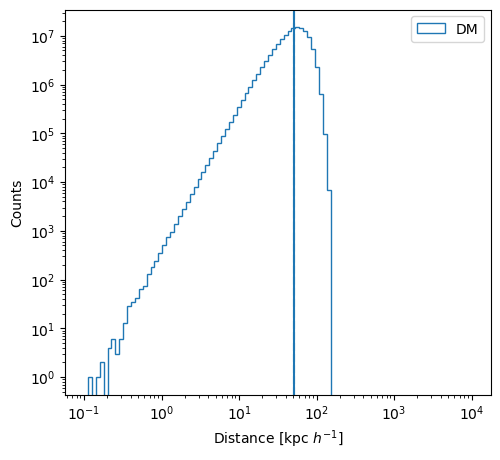

In [60]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5, 5))

ax.set_xscale("log")

ax.hist(dm_dist, bins=np.logspace(-1,4,100), log=True, color="C0", histtype="step", label="DM");

ax.axvline(np.mean(dm_dist), color="C0")
ax.axvline(np.median(dm_dist), color="C0", ls='--')

ax.set_xlabel("Distance $[$kpc $h^{-1}]$")
ax.set_ylabel("Counts")

ax.legend()

# plt.savefig("/mnt/ceph/users/fmaion/projects/bias_priors/figures/Lag_position_distances_gas_DM.pdf", bbox_inches='tight')

In [61]:
print("DM: Mean distance {:.2f}, Median distance {:.2f}".format(np.mean(dm_dist), np.median(dm_dist)))

DM: Mean distance 51.64, Median distance 50.57


In [28]:
basedir = "/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/"
snap = 0

sigma8 = 0.8159
ns     = 0.9667
tau    = 0.0965
sim_format = 'TNG'
cm_50 = bacco.Simulation(verbose=False, basedir=basedir, halo_file='groups_%03d/fof_subhalo_tab_%03d'%(snap,snap),\
           tau=tau,ns = ns, sigma8=sigma8, numpart=512**3, sim_format=sim_format, use_orphans=False)

cm_50.header['Seed'] = 18
cm_50.header['InitialPhase'] = 0.0
cm_50.header['FixedInitialAmplitude'] = False

2025-12-03 16:16:32,122 bacco.sims : Initialising simulation Default
2025-12-03 16:16:32,123 bacco.sims : try /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/groups_000/fof_subhalo_tab_000
2025-12-03 16:16:32,139 bacco.sims : Loading /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/groups_000/fof_subhalo_tab_000
2025-12-03 16:16:36,597 bacco.sims : ...done in 0.0192 s


In [60]:
k = np.logspace(-3, 1, 100)
pk = cm_50.Cosmology.get_powerspec_z(k, 1/(1+127))

Text(0.5, 0, '$k[h/$Mpc$]$')

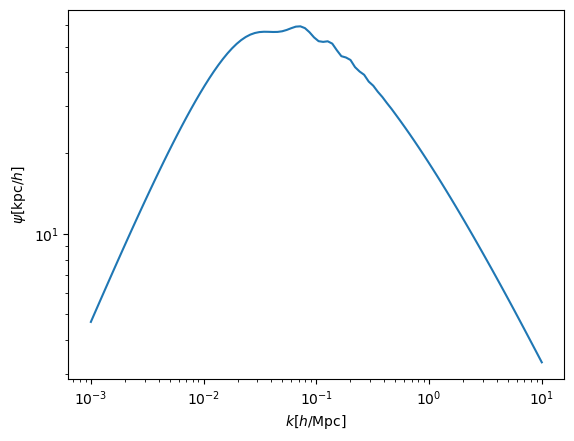

In [68]:
fig, ax = plt.subplots()
ax.plot(k, 1000 * np.sqrt(k**3*pk / (2*np.pi**2) ) / k )
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel("$\\psi[$kpc$/h]$")
ax.set_xlabel("$k[h/$Mpc$]$")

In [52]:
np.sqrt(k**3*pk)/k

0.2643830996158206

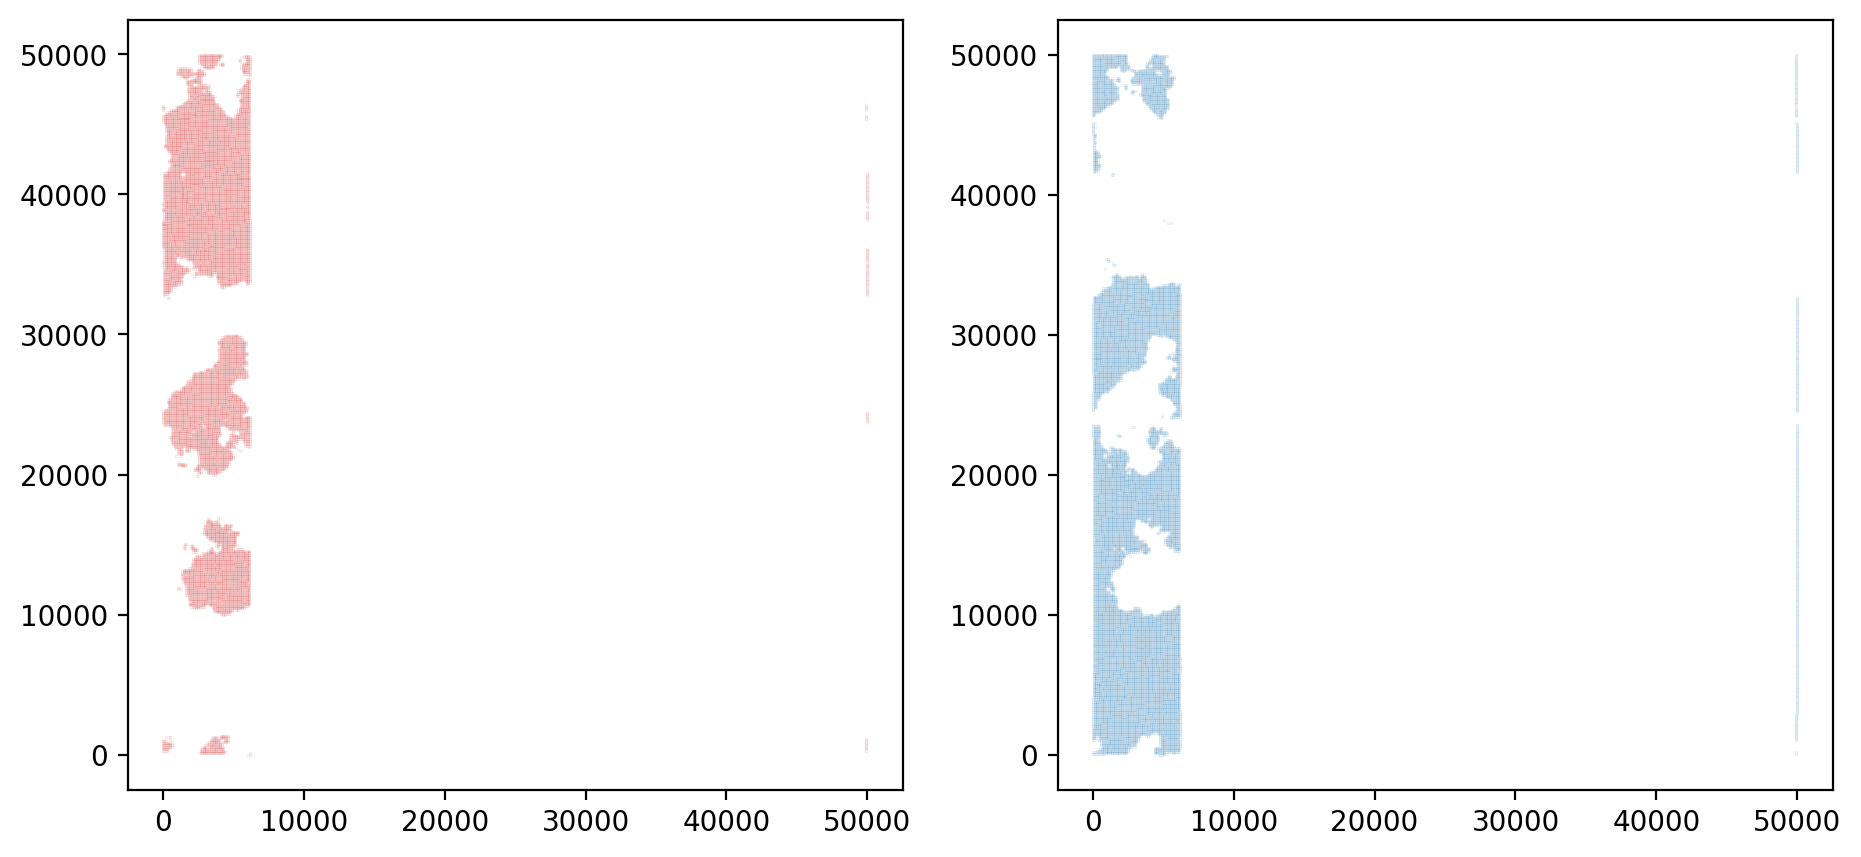

In [64]:
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(11,5))

sel = np.where(gas_pos[:,2] < 50000/512/2)[0]
ax[0].scatter(gas_pos[sel,0], gas_pos[sel,1], s=0.001, color='C3')

sel = np.where(dm_pos[:,2] < 50000/512/2)[0]
ax[1].scatter(gas_pos[sel,0], gas_pos[sel,1], s=0.001, color='C0')

In [ ]:
fig, ax = plt.subplots(dpi=200, figsize=(11,5))

ax.scatter(gas_pos[sel,0], gas_pos[sel,1], s=0.001, color='C3')

sel = np.where(dm_pos[:,2] < 50000/512)[0]
ax[1].scatter(gas_pos[sel,0], gas_pos[sel,1], s=0.001, color='C0')

In [2]:
ngrid = 128
delta_lin = bacco.statistics.compute_mesh(pos=pos/1000, box=50, ngrid=ngrid, interlacing=False)[0]

NameError: name 'bacco' is not defined

In [7]:
from bacco.lss_scaler import lss

In [8]:
cosmology = bacco.Cosmology(**bacco.cosmo_parameters.Planck18)
cosmology.set_expfactor(1/(1+127))

wavemode = 1

Di = cosmology.growthfactor(
    cosmology.expfactor, wavemode=wavemode, cold=False) / cosmology.growthfactor(1.0, wavemode=wavemode, cold=False)
Di2 = cosmology.growthfactorD2(
    cosmology.expfactor) / cosmology.growthfactorD2(1.0)
Di3a = cosmology.growthfactorD3a(cosmology.expfactor)
Di3b = cosmology.growthfactorD3b(cosmology.expfactor)

Di3a = Di**3
Di3b = Di**3

return_density = 1
LPT_order = 2

order_by_order = False
growthrate = cosmology.growthrate(cosmology.expfactor)
redshift_space = 0
sphere_mode = 0

damping_scale = 6
verbose = False
nthreads = 8

kmin = 1e-2
kmax = 1e3

2025-11-25 11:27:35,767 bacco.cosmo :   Warning! 3LPT growth factor (3b) with reps not yet implemented


In [9]:
power_x = cosmology._tabPowerSpectrum_z0['x']
power_y = cosmology._tabPowerSpectrum_z0['y']

In [10]:
grid = (
    lss.lpt_field(
        power_x,
        power_y,
        Di,
        Di2,
        Di3a,
        Di3b,
        growthrate,
        LPT_order, # LPT order
        damping_scale,
        kmin,
        kmax,
        order_by_order,
        ngrid,
        50, # BoxSize
        18, # Seed
        1 / cosmo.expfactor - 1, # z
        1, # Fixed Amplitudes
        0.00, # Initial Phase
        1, # phase type
        0, # Millennium_ICs
        return_density,
        redshift_space,
        sphere_mode,
        nthreads,
        verbose))

NameError: name 'cosmo' is not defined

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(grid[0,:,:,0])
ax[1].imshow(delta_lin[:,:,0])

In [12]:
with h5py.File("/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/snapdir_090/snap_090.0.hdf5", "r") as f:
    print(f.keys())
    for key, value in f['Config'].attrs.items():
        print(key, value)

<KeysViewHDF5 ['Config', 'Header', 'Parameters', 'PartType0', 'PartType1', 'PartType3', 'PartType4', 'PartType5']>
ADAPTIVE_HYDRO_SOFTENING b''
ALLOW_DIRECT_SUMMATION b''
BH_ADIOS_ONLY_ABOVE_MINIMUM_DENSITY b''
BH_ADIOS_RANDOMIZED b''
BH_ADIOS_WIND b''
BH_ADIOS_WIND_WITH_QUASARTHRESHOLD b''
BH_ADIOS_WIND_WITH_VARIABLE_QUASARTHRESHOLD b''
BH_BONDI_DEFAULT b''
BH_DO_NOT_PREVENT_MERGERS b''
BH_EXACT_INTEGRATION b''
BH_NEW_CENTERING b''
BH_PRESSURE_CRITERION b''
BH_THERMALFEEDBACK b''
BH_USE_ALFVEN_SPEED_IN_BONDI b''
BLACK_HOLES b''
CELL_CENTER_GRAVITY b''
CHUNKING b''
COOLING b''
DEBUG b''
DIRECT_SUMMATION_THRESHOLD 4000.0
DOUBLEPRECISION 1.0
DOUBLEPRECISION_FFTW b''
DRAINGAS 3.0
ENFORCE_JEANS_STABILITY_OF_CELLS b''
ENFORCE_JEANS_STABILITY_OF_CELLS_EEOS b''
ENLARGE_DYNAMIC_RANGE_IN_TIME b''
EVALPOTENTIAL b''
FOF b''
FOF_PRIMARY_LINK_TYPES 2.0
FOF_SECONDARY_LINK_TYPES 49.0
FREE_DC_BEFORE_FULL_MESH_CONSTRUCTION b''
GENERATE_TRACER_MC_IN_ICS b''
GFM b''
GFM_AGN_RADIATION b''
GFM_CHEMTAGS b''

In [33]:
import numpy as np

def position_from_total_id(ID, cell_size, x_offset, y_offset, z_offset):
    """
    Compute the species, position, and species-local index for a particle
    in the alternating 64^3 block scheme.

    Arguments:
        ID        - total particle ID (1-indexed)
        cell_size - size of one grid cell

    Returns:
        species     - "gas" or "dm"
        index_local - index inside gas_pos[] or dm_pos[]
        pos         - (x, y, z)
    """

    # Basic constants
    B = 64                  # block size
    N = 512                 # full grid
    NB = N // B             # 8 blocks per dimension
    block_particles = B**3  # 262144

    # Zero-based total ID
    ID0 = ID - 1

    # Which block in total sequence?
    block_id = ID0 // block_particles
    offset_in_block = ID0 % block_particles

    # Species from alternation
    if block_id % 2 == 0:
        species = "gas"
        species_block_index = block_id // 2
    else:
        species = "dm"
        species_block_index = block_id // 2

    # Local species index
    index_local = species_block_index * block_particles + offset_in_block

    # Convert block_id → spatial block coordinates (bx, by, bz)
    # using z-fastest convention
    bz = species_block_index % NB
    by = (species_block_index // NB) % NB
    bx = (species_block_index // (NB * NB)) % NB

    # Block origin
    x0 = bx * B * cell_size
    y0 = by * B * cell_size
    z0 = bz * B * cell_size

    # Offset-in-block → (ix, iy, iz)
    iz = offset_in_block % B
    iy = (offset_in_block // B) % B
    ix = (offset_in_block // (B * B)) % B

    # Final position
    x = x0 + x_offset + ix * cell_size
    y = y0 + y_offset + iy * cell_size
    z = z0 + z_offset + iz * cell_size

    if x > 50000: x -= 50000
    elif x < 0: x += 50000
    if y > 50000: y -= 50000
    elif y < 0: y += 50000
    if z > 50000: z -= 50000
    elif z < 0: z += 50000
    
    return species, index_local, (x, y, z)


In [91]:
position_from_total_id(1, 50000/512)

0.0 0.0 0.0


('gas', 0, (-48.828125, -48.828125, -48.828125))